# Setup and imports
This cell imports PyTorch, data loading utilities, torchvision transforms, and the custom dataset/model classes used throughout the notebook.

In [1]:
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T

from multimodal_dataset import MultiModalDataset
from multimodal_model import MultiModalNet


# Build datasets and loaders
This cell defines the image transforms, loads the train/test CSVs into `MultiModalDataset`, and builds data loaders for batching and shuffling.

In [2]:
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])

train_ds = MultiModalDataset(
    "train.csv",
    transform=transform
)

test_ds = MultiModalDataset(
    "test.csv",
    transform=transform
)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=8, shuffle=False)

print("Train samples:", len(train_ds))
print("Test samples :", len(test_ds))


Train samples: 443
Test samples : 261


# Configure model and optimizer
This cell selects the compute device, initializes the multimodal network, and sets the loss function and optimizer.

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = MultiModalNet(num_classes=3).to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


Device: cpu


# Training step
This cell defines `train_one_epoch()` to run a full training pass, compute loss, and update model weights.

In [4]:
def train_one_epoch(model, loader):

    model.train()
    total_loss = 0.0

    for images, audios, chems, labels in loader:

        images = images.to(device)
        audios = audios.to(device)
        chems  = chems.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images, audios, chems)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


# Evaluation step
This cell defines `evaluate()` to compute accuracy on the test set without updating model weights.

In [5]:
def evaluate(model, loader):

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():

        for images, audios, chems, labels in loader:

            images = images.to(device)
            audios = audios.to(device)
            chems  = chems.to(device)
            labels = labels.to(device)

            outputs = model(images, audios, chems)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total


# Train the model
This cell runs the training loop for a fixed number of epochs and prints loss and test accuracy each epoch.

In [6]:
num_epochs = 10

for epoch in range(num_epochs):

    train_loss = train_one_epoch(model, train_loader)
    test_acc   = evaluate(model, test_loader)

    print(f"Epoch {epoch+1:02d} | loss = {train_loss:.4f} | test acc = {test_acc:.4f}")


c:\Users\HP\Mission-Capstone\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch 01 | loss = 0.8970 | test acc = 0.6092
Epoch 02 | loss = 0.4683 | test acc = 0.6054
Epoch 03 | loss = 0.2866 | test acc = 0.6130
Epoch 04 | loss = 0.1550 | test acc = 0.6590
Epoch 05 | loss = 0.1324 | test acc = 0.6015
Epoch 06 | loss = 0.1217 | test acc = 0.6015
Epoch 07 | loss = 0.1430 | test acc = 0.6782
Epoch 08 | loss = 0.1250 | test acc = 0.6743
Epoch 09 | loss = 0.1151 | test acc = 0.7663
Epoch 10 | loss = 0.0943 | test acc = 0.6782


# Save trained weights
This cell saves the trained model parameters to disk for later inference or analysis.

In [7]:
torch.save(model.state_dict(), "multimodal_model.pt")
print("Model saved.")


Model saved.


# Confusion matrix
This cell generates predictions on the test set and visualizes a confusion matrix for class-wise performance.

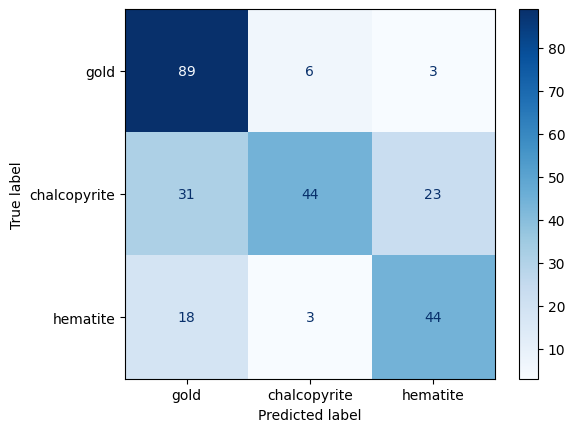

In [14]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def get_predictions(model, loader):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, audios, chems, labels in loader:

            images = images.to(device)
            audios = audios.to(device)
            chems  = chems.to(device)

            outputs = model(images, audios, chems)
            preds = outputs.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)


y_true, y_pred = get_predictions(model, test_loader)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    cm,
    display_labels=["gold", "chalcopyrite", "hematite"]
)


disp.plot(cmap="Blues")
plt.show()


# Extract multimodal fingerprints
This cell collects intermediate embeddings from each modality, concatenates them into a fused fingerprint, and stores them for analysis.

In [9]:
import numpy as np
import pandas as pd

model.eval()

all_embeddings = []
all_labels = []

with torch.no_grad():
    for images, audios, chems, labels in test_loader:

        images = images.to(device)
        audios = audios.to(device)
        chems  = chems.to(device)

        # Extract features from each branch
        f_img  = model.image_enc(images)
        f_aud  = model.audio_enc(audios)
        f_chem = model.chem_enc(chems)

        # Fuse = fingerprint
        fused = torch.cat([f_img, f_aud, f_chem], dim=1)

        all_embeddings.append(fused.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

X = np.vstack(all_embeddings)
y = np.concatenate(all_labels)

print("Fingerprint matrix shape:", X.shape)


Fingerprint matrix shape: (261, 224)


# Save fingerprints to disk
This cell saves the extracted fingerprints and labels to NumPy and CSV files for downstream use.

In [10]:
np.save("test_fingerprints.npy", X)
np.save("test_labels.npy", y)

df = pd.DataFrame(X)
df["label"] = y
df.to_csv("test_fingerprints.csv", index=False)

print("Saved:")
print(" - test_fingerprints.npy")
print(" - test_labels.npy")
print(" - test_fingerprints.csv")


Saved:
 - test_fingerprints.npy
 - test_labels.npy
 - test_fingerprints.csv


# Visualization setup
This cell imports dimensionality-reduction tools and defines readable class names for plotting.

In [11]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

label_names = {
    0: "gold",
    1: "chalcopyrite",
    2: "hematite"
}


# PCA visualization
This cell projects fingerprints to 2D using PCA and plots class-separated clusters.

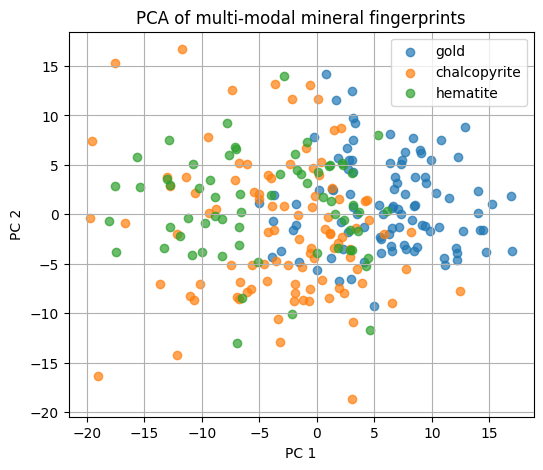

In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6, 5))

for lab in np.unique(y):
    idx = y == lab
    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        label=label_names[lab],
        alpha=0.7
    )

plt.title("PCA of multi-modal mineral fingerprints")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend()
plt.grid(True)
plt.show()


# t-SNE visualization
This cell applies t-SNE to the fingerprints and plots the 2D embedding for class separation.

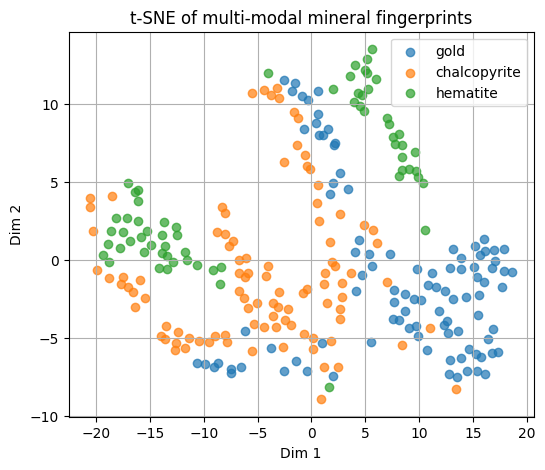

In [13]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(6, 5))

for lab in np.unique(y):
    idx = y == lab
    plt.scatter(
        X_tsne[idx, 0],
        X_tsne[idx, 1],
        label=label_names[lab],
        alpha=0.7
    )

plt.title("t-SNE of multi-modal mineral fingerprints")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.legend()
plt.grid(True)
plt.show()
